# Wildfire Weather Data — EDA & Visualization

Loads the processed CSV splits (produced by `etl_pipeline.py`) and explores feature distributions, correlations, and the synthetic target.

In [2]:
import os, sys, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))
from config import *
print('Config loaded.')

Config loaded.


---
## 1. Load Processed Data

In [3]:
data_dir = 'processed_data'

def read_csv_dir(path):
    files = sorted(glob.glob(os.path.join(path, 'part-*.csv')))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

train = read_csv_dir(os.path.join(data_dir, 'train'))
val   = read_csv_dir(os.path.join(data_dir, 'val'))
test  = read_csv_dir(os.path.join(data_dir, 'test'))

df = pd.concat([train, val, test], ignore_index=True)
print(f'Full dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Full dataset: 1,830,945 rows × 17 cols
  Train: 1,281,321 | Val: 183,401 | Test: 366,223


---
## 2. Feature Distributions

### Window 0 day(s)


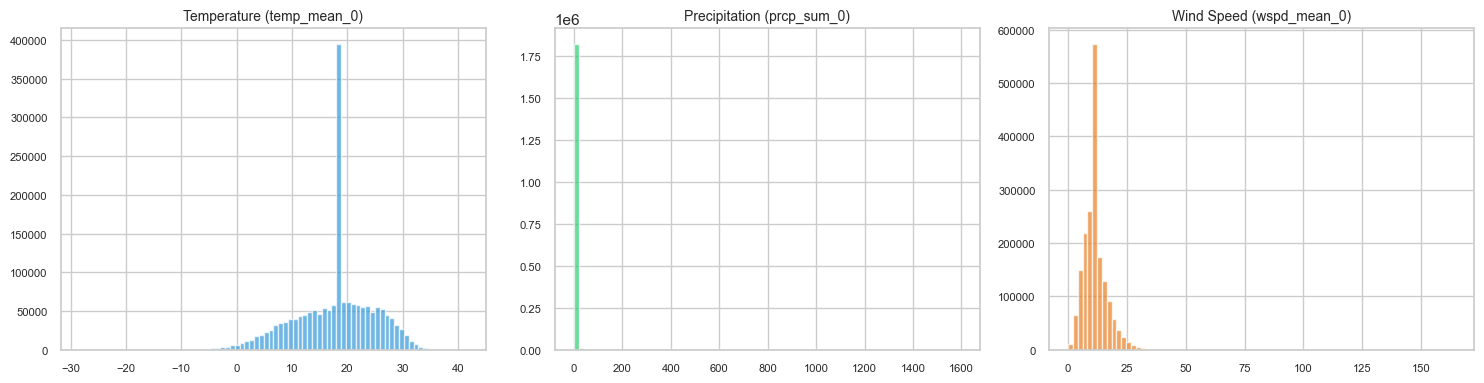

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#3498db", "#2ecc71", "#e67e22"]
titles = ["Temperature", "Precipitation", "Wind Speed"]
cols = ["temp_mean_0", "prcp_sum_0", "wspd_mean_0"]
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.7)
    ax.set_title(f"{title} ({col})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


### Window 10 day(s)


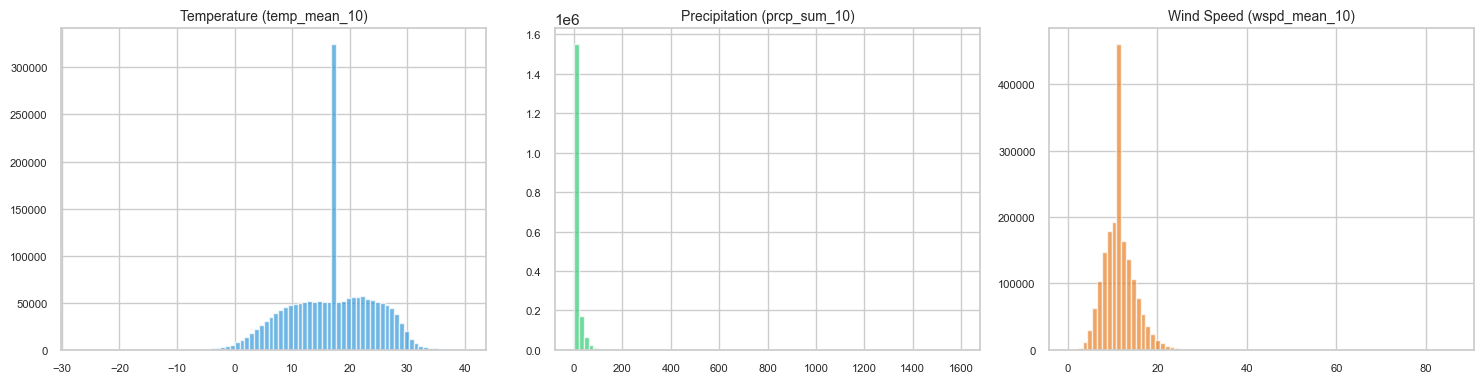

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#3498db", "#2ecc71", "#e67e22"]
titles = ["Temperature", "Precipitation", "Wind Speed"]
cols = ["temp_mean_10", "prcp_sum_10", "wspd_mean_10"]
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.7)
    ax.set_title(f"{title} ({col})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


### Window 30 day(s)


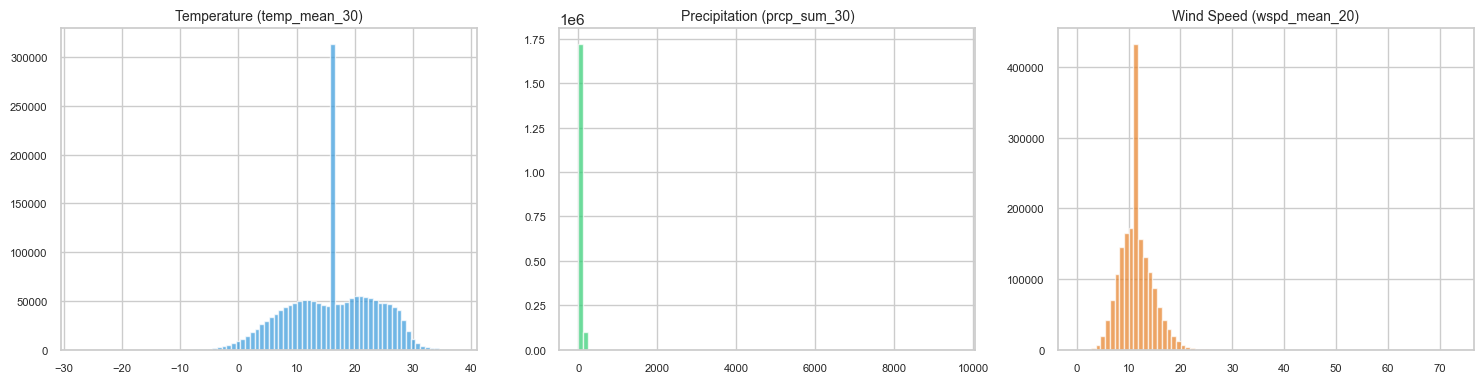

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#3498db", "#2ecc71", "#e67e22"]
titles = ["Temperature", "Precipitation", "Wind Speed"]
cols = ["temp_mean_30", "prcp_sum_30", "wspd_mean_20"]
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.7)
    ax.set_title(f"{title} ({col})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


### Window 60 day(s)


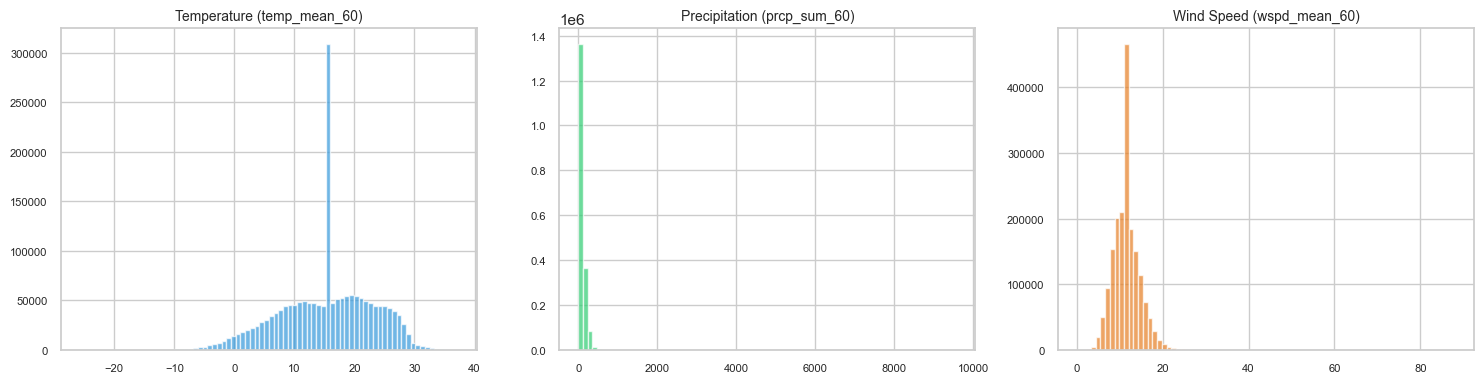

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#3498db", "#2ecc71", "#e67e22"]
titles = ["Temperature", "Precipitation", "Wind Speed"]
cols = ["temp_mean_60", "prcp_sum_60", "wspd_mean_60"]
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.7)
    ax.set_title(f"{title} ({col})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


### Window 180 day(s)


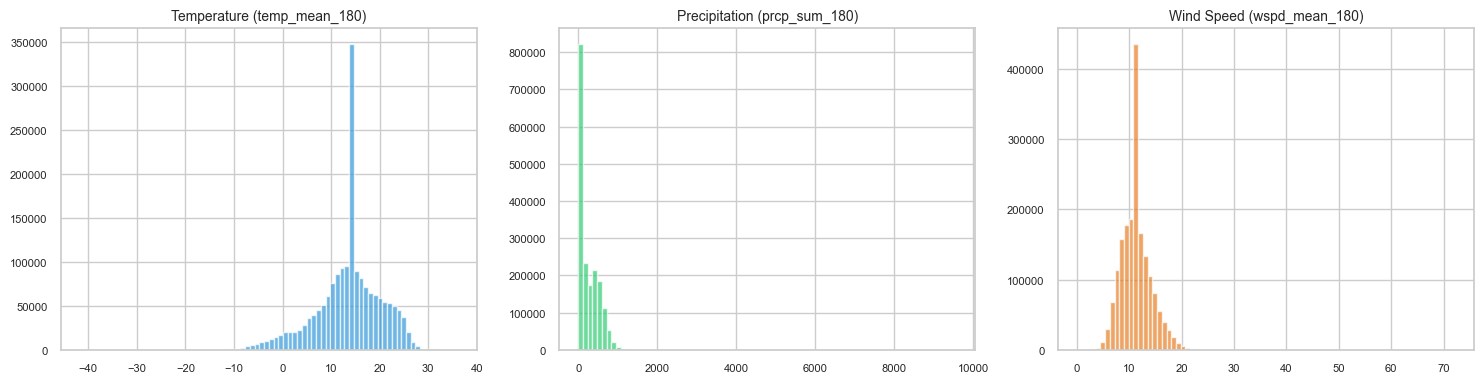

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#3498db", "#2ecc71", "#e67e22"]
titles = ["Temperature", "Precipitation", "Wind Speed"]
cols = ["temp_mean_180", "prcp_sum_180", "wspd_mean_180"]
for ax, col, color, title in zip(axes, cols, colors, titles):
    ax.hist(df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.7)
    ax.set_title(f"{title} ({col})", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


---
## 3. Correlation Matrix

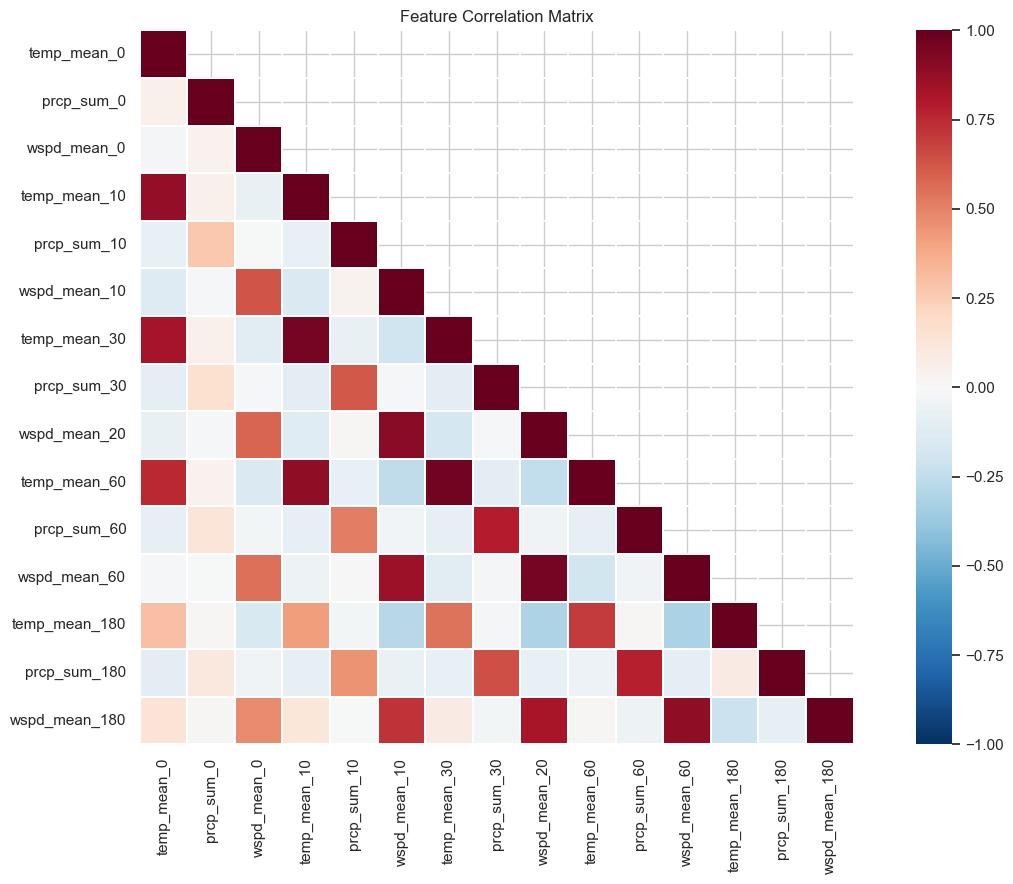

In [4]:
corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
corr_unstack = corr.unstack()
high = corr_unstack[(corr_unstack < 1.0) & (corr_unstack.abs() > 0.85)].sort_values(ascending=False)
print(f'Pairs with |r| > 0.85 ({len(high)}):')
for (c1, c2), v in high.items():
    print(f'  {c1:20s} vs {c2:20s}:  r = {v:.3f}')

Pairs with |r| > 0.85 (16):
  temp_mean_30         vs temp_mean_60        :  r = 0.962
  temp_mean_60         vs temp_mean_30        :  r = 0.962
  wspd_mean_20         vs wspd_mean_60        :  r = 0.958
  wspd_mean_60         vs wspd_mean_20        :  r = 0.958
  temp_mean_30         vs temp_mean_10        :  r = 0.955
  temp_mean_10         vs temp_mean_30        :  r = 0.955
  wspd_mean_20         vs wspd_mean_10        :  r = 0.902
  wspd_mean_10         vs wspd_mean_20        :  r = 0.902
  wspd_mean_180        vs wspd_mean_60        :  r = 0.888
  wspd_mean_60         vs wspd_mean_180       :  r = 0.888
  temp_mean_60         vs temp_mean_10        :  r = 0.883
  temp_mean_10         vs temp_mean_60        :  r = 0.883
  temp_mean_10         vs temp_mean_0         :  r = 0.879
  temp_mean_0          vs temp_mean_10        :  r = 0.879
  wspd_mean_10         vs wspd_mean_60        :  r = 0.856
  wspd_mean_60         vs wspd_mean_10        :  r = 0.856


---
## 4. Target (Fire Severity) Distribution

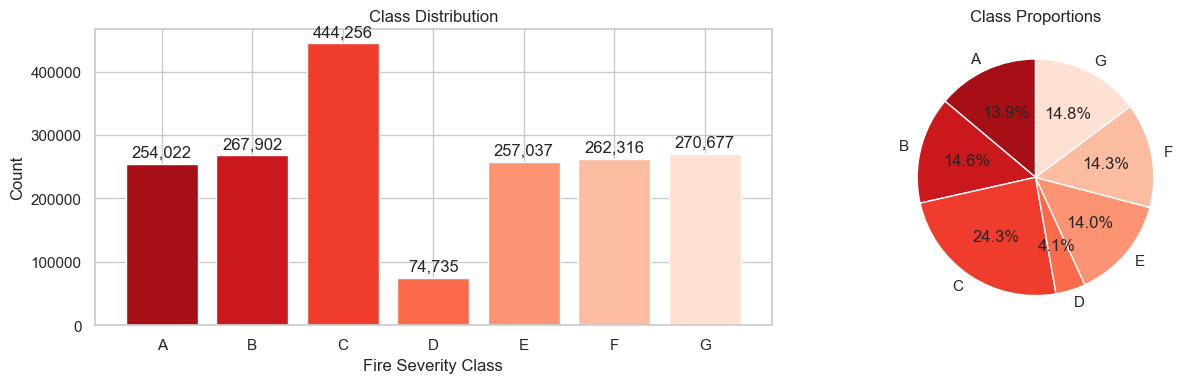

Synthetic target: 7 near-balanced classes (A = lowest, G = highest risk)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(CLASS_NAMES, counts.values, color=sns.color_palette('Reds_r', NUM_CLASSES))
axes[0].bar_label(axes[0].containers[0], labels=[f'{c:,}' for c in counts.values], padding=3)
axes[0].set_xlabel('Fire Severity Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')

axes[1].pie(counts.values, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=sns.color_palette('Reds_r', NUM_CLASSES), startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()
print(f'Synthetic target: {NUM_CLASSES} near-balanced classes (A = lowest, G = highest risk)')

---
## 5. Feature-Target Relationships

### Mean Temperature by Severity Class


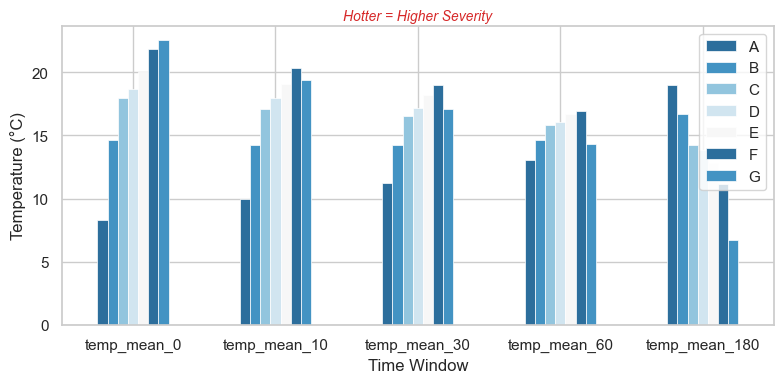

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
cols = [c for c in FEATURE_COLS if c.startswith("temp")]
plot_data = grouped[cols].T
plot_data.columns = CLASS_NAMES
plot_data.plot(kind="bar", ax=ax, color=window_colors[:len(cols)],
               edgecolor="white", linewidth=0.5, legend=True)
# ax.set_title("Mean Temperature by Severity Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Time Window")
ax.set_ylabel("Temperature (°C)")
ax.tick_params(axis="x", rotation=0)
ax.annotate("Hotter = Higher Severity", xy=(0.5, 1.02), xycoords="axes fraction",
            ha="center", fontsize=10, color="#d62728", fontstyle="italic")
plt.tight_layout()
plt.show()


### Mean Precipitation by Severity Class


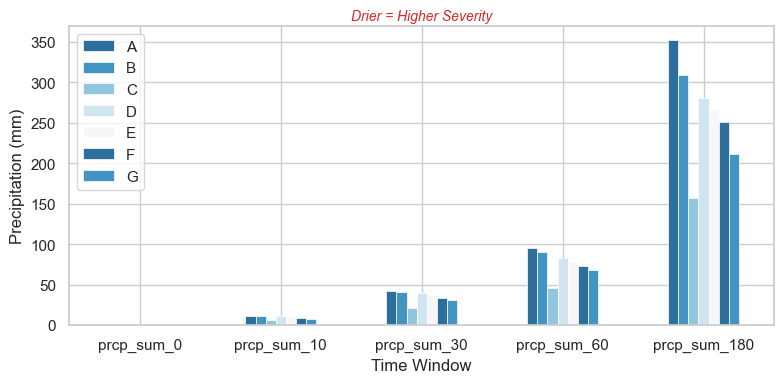

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
cols = [c for c in FEATURE_COLS if c.startswith("prcp")]
plot_data = grouped[cols].T
plot_data.columns = CLASS_NAMES
plot_data.plot(kind="bar", ax=ax, color=window_colors[:len(cols)],
               edgecolor="white", linewidth=0.5, legend=True)
# ax.set_title("Mean Precipitation by Severity Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Time Window")
ax.set_ylabel("Precipitation (mm)")
ax.tick_params(axis="x", rotation=0)
ax.annotate("Drier = Higher Severity", xy=(0.5, 1.02), xycoords="axes fraction",
            ha="center", fontsize=10, color="#d62728", fontstyle="italic")
plt.tight_layout()
plt.show()


### Mean Wind Speed by Severity Class


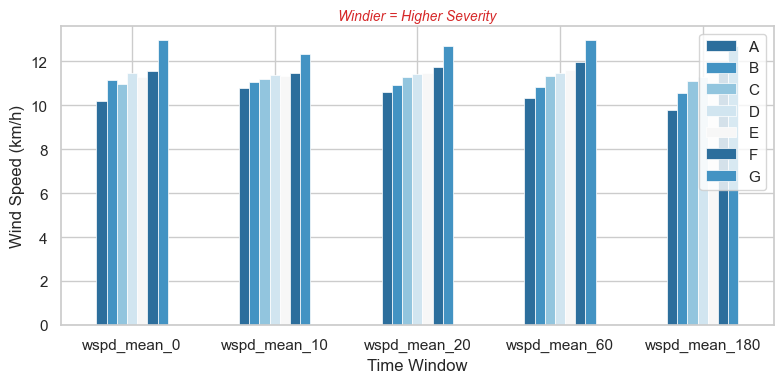

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
cols = [c for c in FEATURE_COLS if c.startswith("wspd")]
plot_data = grouped[cols].T
plot_data.columns = CLASS_NAMES
plot_data.plot(kind="bar", ax=ax, color=window_colors[:len(cols)],
               edgecolor="white", linewidth=0.5, legend=True)
# ax.set_title("Mean Wind Speed by Severity Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Time Window")
ax.set_ylabel("Wind Speed (km/h)")
ax.tick_params(axis="x", rotation=0)
ax.annotate("Windier = Higher Severity", xy=(0.5, 1.02), xycoords="axes fraction",
            ha="center", fontsize=10, color="#d62728", fontstyle="italic")
plt.tight_layout()
plt.show()


---
## 6. Summary Stats

In [8]:
print('Feature summary statistics:')
df[FEATURE_COLS].describe().round(2)

Feature summary statistics:


,temp_mean_0,prcp_sum_0,wspd_mean_0,temp_mean_10,prcp_sum_10,wspd_mean_10,temp_mean_30,prcp_sum_30,wspd_mean_20,temp_mean_60,prcp_sum_60,wspd_mean_60,temp_mean_180,prcp_sum_180,wspd_mean_180
count,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00,1830945.00
mean,17.69,0.56,11.33,16.81,8.89,11.36,16.15,33.23,11.45,15.34,72.49,11.49,13.49,248.39,11.26
std,7.24,3.41,5.01,7.31,17.82,3.38,7.41,51.48,3.11,7.62,101.38,3.02,6.71,269.29,2.87
min,-28.30,0.00,0.00,-26.86,0.00,0.00,-27.27,0.00,0.00,-25.78,0.00,0.00,-41.80,0.00,0.00
25%,13.40,0.00,8.30,11.84,0.00,9.26,11.00,0.00,9.48,10.33,0.00,9.56,10.24,5.10,9.39
50%,18.24,0.00,10.63,17.08,0.50,11.07,16.46,11.87,11.22,15.84,34.95,11.29,13.82,160.30,11.03
75%,22.50,0.00,13.32,22.10,10.10,13.08,21.61,52.00,13.11,20.75,121.75,13.14,17.68,439.65,12.77
max,41.60,1596.80,164.20,40.35,1598.40,86.45,37.72,9580.70,72.96,37.25,9580.70,88.08,36.13,9580.70,72.17


In [9]:
print(f'\nMissing values after imputation: {df[FEATURE_COLS].isnull().sum().sum()}')
print(f'Total records: {len(df):,}')
print(f'Synthetic target classes: {list(df[TARGET_COL].unique())}')


Missing values after imputation: 0
Total records: 1,830,945
Synthetic target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
